In [6]:
import numpy as np
import pandas as pd
import sys


def generate_quantum_bits(n_samples=1000, n_bits=10):
    try:
        from qiskit import QuantumCircuit, Aer, execute
        backend = Aer.get_backend('aer_simulator')

        qc = QuantumCircuit(n_bits, n_bits)
        qc.h(range(n_bits))       # Apply Hadamard to create superposition
        qc.measure_all()          # Measure all qubits

        job = execute(qc, backend=backend, shots=n_samples)
        result = job.result()
        counts = result.get_counts()

  
        data = []
        for bitstring, count in counts.items():
            bits = list(bitstring[::-1])  # Reverse to match qubit order
            for _ in range(count):
                data.append([int(b) for b in bits])
        data = np.array(data)
        print(f" Generated {data.shape[0]} samples using Qiskit quantum simulator.")
        return data

    except Exception as e:
        print(" Qiskit not available or simulator failed. Using NumPy pseudo-random numbers.", file=sys.stderr)
        rng = np.random.default_rng()
        return rng.integers(0, 2, size=(n_samples, n_bits))


N_SAMPLES = 1000    # number of rows
N_BITS = 10         # number of bits (features)

# --- Generate the dataset ---
bits = generate_quantum_bits(N_SAMPLES, N_BITS)

# --- Create labels (parity of first 3 bits) ---
labels = bits[:, 0] ^ bits[:, 1] ^ bits[:, 2]   # XOR pattern as label

# --- Combine features + label ---
columns = [f'bit_{i}' for i in range(N_BITS)] + ['label']
df = pd.DataFrame(np.column_stack([bits, labels]), columns=columns)

# --- Save to CSV ---
output_file = "quantum_random_dataset.csv"
df.to_csv(output_file, index=False)

print(f" Dataset saved to: {output_file}")
print(df.head(10))



 Dataset saved to: quantum_random_dataset.csv
   bit_0  bit_1  bit_2  bit_3  bit_4  bit_5  bit_6  bit_7  bit_8  bit_9  label
0      1      0      0      0      0      0      1      0      1      0      1
1      1      1      1      1      0      1      0      1      1      0      1
2      0      0      0      1      1      1      1      1      1      0      0
3      1      1      1      0      0      0      1      0      1      1      1
4      0      0      1      1      0      0      1      1      1      1      1
5      1      0      1      1      1      0      0      0      0      1      0
6      0      0      0      1      1      1      1      0      0      1      0
7      1      0      0      1      0      1      0      0      1      1      1
8      1      1      0      0      1      0      0      0      1      0      0
9      1      0      0      1      1      0      1      1      1      0      1


 Qiskit not available or simulator failed. Using NumPy pseudo-random numbers.


In [11]:
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def generate_bits_qiskit(n_samples=1000, n_bits=10, verbose=True):
    """
    Generate quantum random bits using Qiskit Aer simulator.
    Each sample is a measurement of 'n_bits' qubits in superposition.
    Returns: numpy array of shape (n_samples, n_bits)
    """
    # Create a quantum circuit with n_bits qubits and classical bits
    qc = QuantumCircuit(n_bits, n_bits)
    qc.h(range(n_bits))              # Put each qubit into superposition
    qc.measure(range(n_bits), range(n_bits))  # Measure all qubits

    # Initialize Aer simulator
    sim = AerSimulator()

    # Run the circuit n_samples times (shots)
    job = sim.run(qc, shots=n_samples)
    result = job.result()
    counts = result.get_counts()

    # Expand counts (bitstring → multiple rows)
    bit_rows = []
    for bitstring, count in counts.items():
        bits = list(bitstring[::-1])  # Reverse bit order for consistency
        for _ in range(count):
            bit_rows.append([int(b) for b in bits])

    bit_array = np.array(bit_rows)

    if verbose:
        print(f" Generated {bit_array.shape[0]} samples using Qiskit Aer simulator.")
        print("Example output (first 5 samples):")
        print(bit_array[:5])

    return bit_array



# Function: Add labels (learnable pattern)

def make_labels(bits, informative_bits=(0, 1, 2)):
    """
    Create labels based on the XOR (parity) of selected bits.
    Label = 1 if an odd number of the selected bits are 1, else 0.
    """
    selected = bits[:, informative_bits]
    labels = selected.sum(axis=1) % 2
    return labels



# Main execution

if __name__ == "__main__":
    N_SAMPLES = 1000   # number of rows (measurements)
    N_BITS = 10        # number of qubits (features)

    # Generate quantum random bits
    bits = generate_bits_qiskit(N_SAMPLES, N_BITS)

    # Create labels (based on first 3 bits)
    labels = make_labels(bits, informative_bits=(0, 1, 2))

    # Combine features + label
    columns = [f"bit_{i}" for i in range(N_BITS)] + ["label"]
    df = pd.DataFrame(np.column_stack([bits, labels]), columns=columns)

    # Save to CSV
    output_file = "quantum_random_dataset.csv"
    df.to_csv(output_file, index=False)

    print("\n Dataset saved successfully!")
    print(f"File: {output_file}")
    print(df.head(10))

 Generated 1000 samples using Qiskit Aer simulator.
Example output (first 5 samples):
[[1 1 1 0 1 1 1 1 1 1]
 [1 0 1 1 0 0 0 0 0 1]
 [1 0 1 1 0 0 0 0 0 1]
 [1 0 0 1 1 1 0 0 0 0]
 [0 0 1 0 1 1 1 0 1 1]]

 Dataset saved successfully!
File: quantum_random_dataset.csv
   bit_0  bit_1  bit_2  bit_3  bit_4  bit_5  bit_6  bit_7  bit_8  bit_9  label
0      1      1      1      0      1      1      1      1      1      1      1
1      1      0      1      1      0      0      0      0      0      1      0
2      1      0      1      1      0      0      0      0      0      1      0
3      1      0      0      1      1      1      0      0      0      0      1
4      0      0      1      0      1      1      1      0      1      1      1
5      0      0      1      0      1      1      1      0      1      1      1
6      0      0      0      1      0      0      1      0      0      0      0
7      0      0      0      1      0      0      1      0      0      0      0
8      0      0      0  

In [12]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer

# Create a Quantum Circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)
qc.x(0)              # Apply X gate
qc.measure(0, 0)     # Measure qubit

# Use the Aer simulator backend
sim = Aer.get_backend("aer_simulator")

# Run the simulation
job = sim.run(qc, shots=1024)
result = job.result()

# Get and print the counts
counts = result.get_counts()
print(counts)


{'1': 1024}


In [13]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer

# Create a Quantum Circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Initialize qubit in |1> state
qc.initialize([0, 1], 0)

# Apply X gate
qc.x(0)

# Measure
qc.measure(0, 0)

# Run simulation
sim = Aer.get_backend("aer_simulator")
result = sim.run(qc, shots=1024).result()

# Print measurement counts
print(result.get_counts())


{'0': 1024}


In [1]:
# Day 6: Quantum Teleportation of |+>
# Works with modern Qiskit (AerSimulator).

import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

def build_teleport_circuit(verify_statevector=False):
    """
    Qubit map:
      q0 = message qubit |ψ> (held by Alice initially)
      q1 = Alice's entangled half
      q2 = Bob's entangled half (destination)
    Classical bits:
      c0, c1 record Alice's two measurement outcomes
      c2 records Bob's X-basis outcome for verification
    """
    qc = QuantumCircuit(3, 3)  # 3 qubits, 3 classical bits

    # --- 0) Prepare the message state |ψ> = |+> on q0
    qc.h(0)  # |+> = H|0>

    # --- 1) Create Bell pair between q1 (Alice) and q2 (Bob)
    qc.h(1)
    qc.cx(1, 2)

    # --- 2) Alice's Bell-basis measurement on (q0, q1)
    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)  # m1
    qc.measure(1, 1)  # m2
 # --- 3) Bob's conditional corrections on q2
    # Apply X if m2 == 1
    qc.x(2).c_if(1, 1)  # classical bit index 1 holds m2
    # Apply Z if m1 == 1
    qc.z(2).c_if(0, 1)  # classical bit index 0 holds m1

    # --- 4) Verify: measure Bob in X-basis (H then Z-measure)
    qc.h(2)
    qc.measure(2, 2)  # c2 holds Bob's X-basis result

    return qc

def run_teleport(shots=1024, show_counts=True, show_sv=True):
    qc = build_teleport_circuit()
    sim = AerSimulator()

    # (Optional) statevector check: run until before final X-basis measurement
    if show_sv:
        qc_sv = build_teleport_circuit()
        # Remove the final H and measurement on Bob to inspect the state first:
        # We'll rebuild a version that ends right after corrections
        qc_before_measure = QuantumCircuit(3, 2)  # only Alice's two classical bits
        # Recreate circuit up to corrections:
        qc_before_measure.h(0)
        qc_before_measure.h(1); qc_before_measure.cx(1, 2)
        qc_before_measure.cx(0, 1); qc_before_measure.h(0)
        qc_before_measure.measure(0, 0); qc_before_measure.measure(1, 1)
        # Conditional corrections on q2 based on classical bits are not supported in pure Statevector,
        # so we inspect success statistically with shots rather than exact state pre-measurement.
        pass

# Execute the full circuit with measurements
    job = sim.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    if show_counts:
        print("Measurement counts (c2 c1 c0):")  # c2=Bob X-basis, c1=m2, c0=m1 (note print order)
        print(counts)

    # Compute Bob-in-X success rate: c2=0 means measured |+> in X basis
    total = sum(counts.values())
    plus_counts = sum(v for bitstr, v in counts.items() if bitstr[2] == '0')  # bit order: c2 c1 c0
    print(f"\nBob measured in X-basis = 0 (|+>): {plus_counts}/{total} ≈ {plus_counts/total:.3f}")

run_teleport()

AttributeError: 'InstructionSet' object has no attribute 'c_if'

In [2]:
# Day 6: Quantum Teleportation of |+>
# Works with modern Qiskit (AerSimulator).

import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

def build_teleport_circuit(verify_statevector=False):
    """
    Qubit map:
      q0 = message qubit |ψ> (held by Alice initially)
      q1 = Alice's entangled half
      q2 = Bob's entangled half (destination)
    Classical bits:
      c0, c1 record Alice's two measurement outcomes
      c2 records Bob's X-basis outcome for verification
    """
    qc = QuantumCircuit(3, 3)  # 3 qubits, 3 classical bits


# 0) Prepare the message state |ψ> = |+> on q0
    qc.h(0)

    # 1) Create Bell pair between q1 (Alice) and q2 (Bob)
    qc.h(1)
    qc.cx(1, 2)

    # 2) Alice's Bell-basis measurement on (q0, q1)
    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)  # m1 -> c0
    qc.measure(1, 1)  # m2 -> c1

    # 3) Bob's conditional corrections on q2 (modern control-flow)
    # If m2 == 1, apply X to q2
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(2)
    # If m1 == 1, apply Z to q2
    with qc.if_test((qc.clbits[0], 1)):
        qc.z(2)

    # 4) Verify: measure Bob in X-basis
    qc.h(2)
    qc.measure(2, 2)  # c2 holds Bob's X-basis result

    return qc

def run_teleport(shots=1024, show_counts=True, show_sv=True):
    qc = build_teleport_circuit()
    sim = AerSimulator()

    # (Optional) statevector check skipped (feed-forward uses classical control)

    job = sim.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    if show_counts:
        print("Measurement counts (printed as bitstring 'c2 c1 c0'):")
        print(counts)

    # IMPORTANT: Qiskit prints bitstrings MSB->LSB; with c2,c1,c0 mapped to 2,1,0,
    # the LEFTMOST char is c2. We want c2 == '0' for |+> in X-basis.
    total = sum(counts.values())
    plus_counts = sum(v for bitstr, v in counts.items() if bitstr[0] == '0')
    print(f"\nBob measured in X-basis = 0 (|+>): {plus_counts}/{total} ≈ {plus_counts/total:.3f}")

run_teleport()

Measurement counts (printed as bitstring 'c2 c1 c0'):
{'001': 256, '011': 257, '010': 269, '000': 242}

Bob measured in X-basis = 0 (|+>): 1024/1024 ≈ 1.000


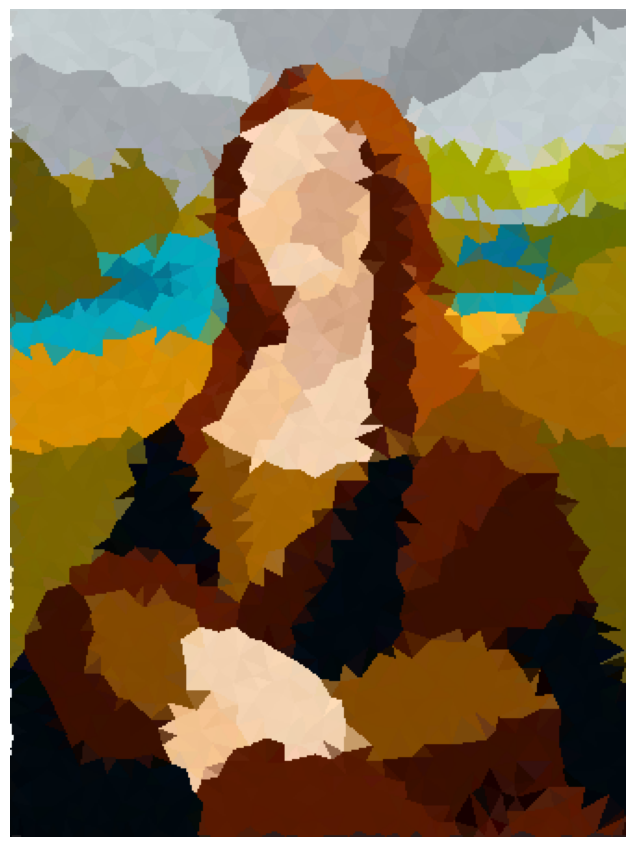

✓ Saved low-poly art to mona_lowpoly.png (size: 332×446, points: 1600)


In [8]:
# === Low-Poly Generator (edge-biased, quantum-seeded) ===
import os, math
import numpy as np
from PIL import Image, ImageFilter, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# ---------- Quantum-seeded RNG (works even if Qiskit missing) ----------
def quantum_seed_256():
    try:
        from qiskit import QuantumCircuit, transpile
        from qiskit_aer import AerSimulator
        sim = AerSimulator()
        qc = QuantumCircuit(256, 256)
        qc.h(range(256)); qc.measure(range(256), range(256))
        tqc = transpile(qc, sim, optimization_level=0)
        res = sim.run(tqc, shots=1, memory=True).result()
        bits = res.get_memory()[0]
        return int(bits, 2)
    except Exception:
        return int.from_bytes(os.urandom(32), "big")

RNG = np.random.default_rng(quantum_seed_256())

# ---------- Helpers ----------
def to_np(img):
    return np.asarray(img)

def from_np(arr):
    return Image.fromarray(arr)

def resize_for_speed(img, max_side=900):
    w, h = img.size
    scale = min(1.0, max_side / max(w, h))
    if scale < 1.0:
        img = img.resize((int(w*scale), int(h*scale)), Image.Resampling.LANCZOS)
    return img

def sobel_edges(img_gray_np):
    # quick Sobel (no SciPy needed)
    g = img_gray_np.astype(np.float32) / 255.0
    Kx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)
    Ky = np.array([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=np.float32)
    # pad + conv
    gp = np.pad(g, 1, mode="edge")
    Gx = (gp[:-2,:-2]*Kx[0,0] + gp[:-2,1:-1]*Kx[0,1] + gp[:-2,2:]*Kx[0,2] +
          gp[1:-1,:-2]*Kx[1,0] + gp[1:-1,1:-1]*Kx[1,1] + gp[1:-1,2:]*Kx[1,2] +
          gp[2:, :-2]*Kx[2,0] + gp[2:, 1:-1]*Kx[2,1] + gp[2:, 2:]*Kx[2,2])
    Gy = (gp[:-2,:-2]*Ky[0,0] + gp[:-2,1:-1]*Ky[0,1] + gp[:-2,2:]*Ky[0,2] +
          gp[1:-1,:-2]*Ky[1,0] + gp[1:-1,1:-1]*Ky[1,1] + gp[1:-1,2:]*Ky[1,2] +
          gp[2:, :-2]*Ky[2,0] + gp[2:, 1:-1]*Ky[2,1] + gp[2:, 2:]*Ky[2,2])
    mag = np.hypot(Gx, Gy)
    mag /= (mag.max() + 1e-8)
    return mag

def sample_points_edge_biased(w, h, edge_map, n_points=1200, min_dist=8, border_pts=True):
    """
    Edge-aware dart throwing:
    - More samples where edges are strong
    - Enforces a soft minimum distance using grid hashing
    """
    pts = []
    if border_pts:
        # ring of border points to keep triangulation bounded
        n_b = 50
        xs = np.linspace(0, w-1, n_b, dtype=np.float32)
        ys = np.linspace(0, h-1, n_b, dtype=np.float32)
        for x in xs:
            pts.append((x, 0)); pts.append((x, h-1))
        for y in ys:
            pts.append((0, y)); pts.append((w-1, y))

    cell = max(1, int(min_dist))
    grid_w, grid_h = (w + cell - 1)//cell, (h + cell - 1)//cell
    grid = [[[] for _ in range(grid_w)] for __ in range(grid_h)]

    def can_place(x, y):
        gx, gy = int(x)//cell, int(y)//cell
        for yy in range(max(0, gy-2), min(grid_h, gy+3)):
            for xx in range(max(0, gx-2), min(grid_w, gx+3)):
                for (px, py) in grid[yy][xx]:
                    if (px-x)**2 + (py-y)**2 < (min_dist**2):
                        return False
        return True

    def put(x, y):
        pts.append((x, y))
        grid[int(y)//cell][int(x)//cell].append((x, y))

    # bias function (edges in [0,1])
    edge_pow = 1.25  # >1 increases edge preference
    target = n_points + len(pts)
    attempts = 0
    while len(pts) < target and attempts < target*50:
        attempts += 1
        x = RNG.random() * (w-1)
        y = RNG.random() * (h-1)
        e = edge_map[int(y), int(x)]
        p = (0.25 + 0.75 * (e ** edge_pow))  # 25% base + edge bias
        if RNG.random() < p and can_place(x, y):
            put(x, y)

    return np.array(pts, dtype=np.float32)

def triangulate_and_paint(img_rgb_np, pts, show_edges=False, line_alpha=0.0):
    h, w, _ = img_rgb_np.shape
    tri = mtri.Triangulation(pts[:,0], pts[:,1])
    # draw polygons on a new image
    out = Image.new("RGB", (w, h), (0,0,0))
    draw = ImageDraw.Draw(out)

    # average color per triangle by centroid sampling (fast, good looking)
    for tri_ix in tri.triangles:
        poly = pts[tri_ix]  # (3,2)
        cx = np.clip(np.mean(poly[:,0]), 0, w-1)
        cy = np.clip(np.mean(poly[:,1]), 0, h-1)
        c = tuple(map(int, img_rgb_np[int(cy), int(cx), :]))
        xy = [(float(poly[0,0]), float(poly[0,1])),
              (float(poly[1,0]), float(poly[1,1])),
              (float(poly[2,0]), float(poly[2,1]))]
        draw.polygon(xy, fill=c)
        if show_edges and line_alpha > 0:
            # subtle wireframe if desired
            la = int(255*line_alpha)
            draw.line([xy[0], xy[1], xy[2], xy[0]], fill=(0,0,0,la), width=1)

    return out

def lowpoly_image(
    img_path,
    max_side=900,
    n_points=1200,
    min_dist=8,
    edge_enhance=True,
    show_preview=True,
    save_path="lowpoly.png"
):
    img = Image.open(img_path).convert("RGB")
    img = resize_for_speed(img, max_side=max_side)
    w, h = img.size
    gray = img.convert("L")

    # Edge map: PIL edges + Sobel (combined) for robust detail
    pil_edge = np.asarray(gray.filter(ImageFilter.FIND_EDGES), dtype=np.float32)/255.0
    sob_edge = sobel_edges(np.asarray(gray))
    edge_map = np.clip(0.5*pil_edge + 0.5*sob_edge, 0, 1)
    if edge_enhance:
        edge_map = np.clip(edge_map**0.9, 0, 1)  # gentle boost

    pts = sample_points_edge_biased(w, h, edge_map, n_points=n_points, min_dist=min_dist, border_pts=True)
    out = triangulate_and_paint(np.asarray(img), pts, show_edges=False)

    out.save(save_path, "PNG")
    if show_preview:
        plt.figure(figsize=(8, 8*h/w))
        plt.imshow(out); plt.axis("off"); plt.show()
    print(f"✓ Saved low-poly art to {save_path} (size: {w}×{h}, points: {len(pts)})")

# ---------- Run it ----------
# Put your source image in the working folder, e.g., "monalisa.jpg"
lowpoly_image(
    img_path="monalisa1.jpg",   # <-- change if your file is named differently
    max_side=900,              # resize for speed; increase for higher detail
    n_points=1400,             # more points → more facets
    min_dist=7,                # minimum pixel spacing between points
    edge_enhance=True,
    show_preview=True,
    save_path="mona_lowpoly.png"
)



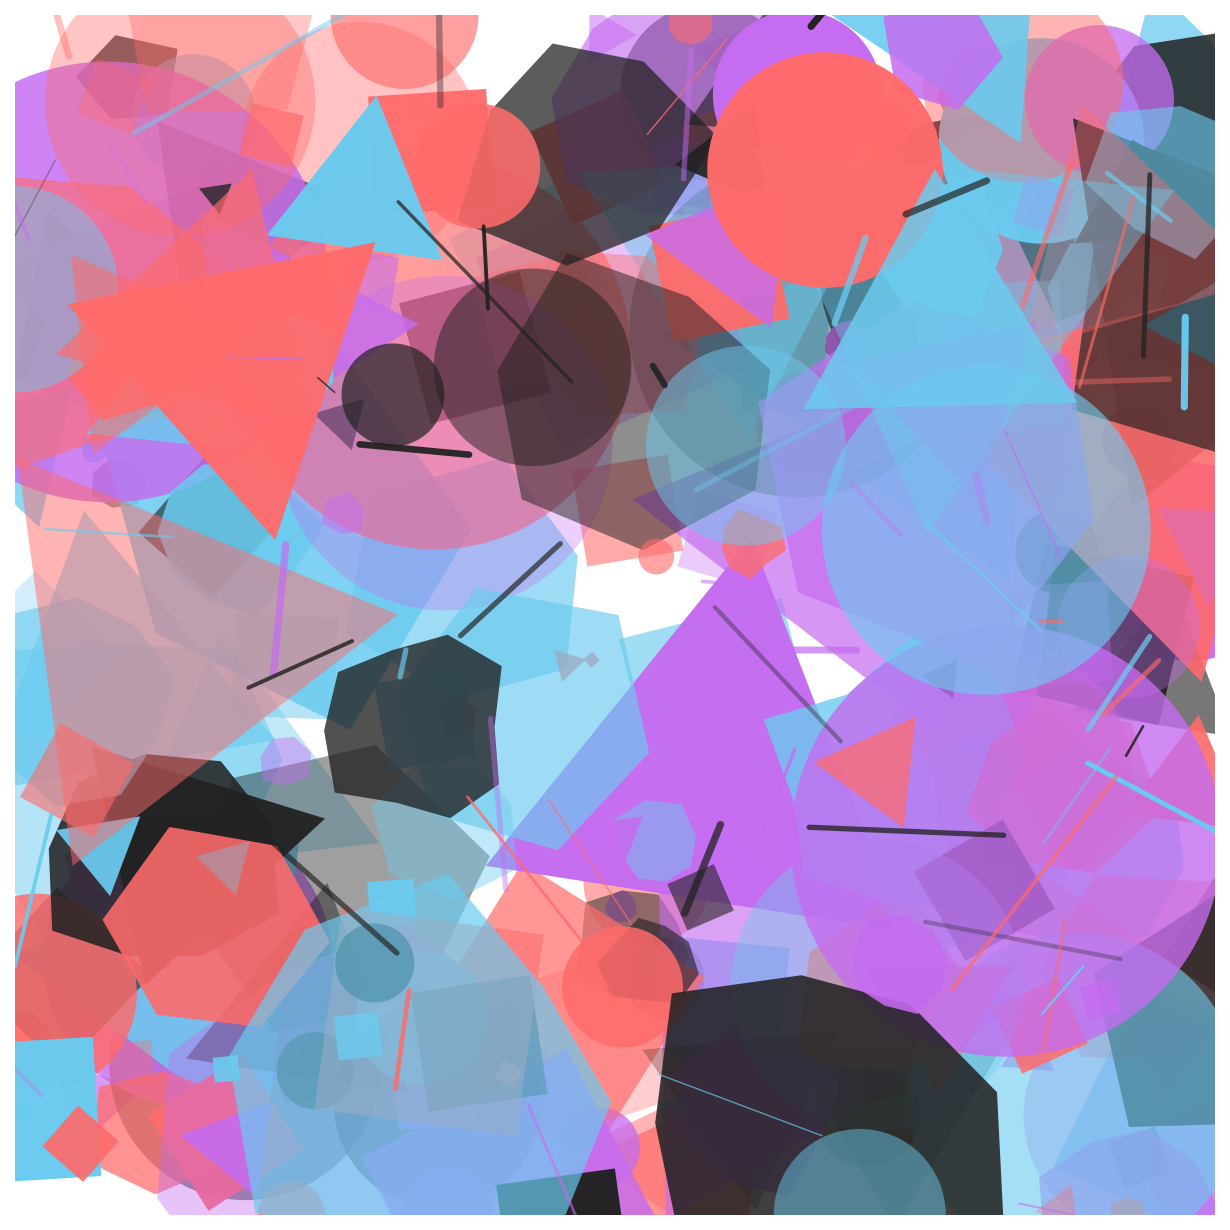

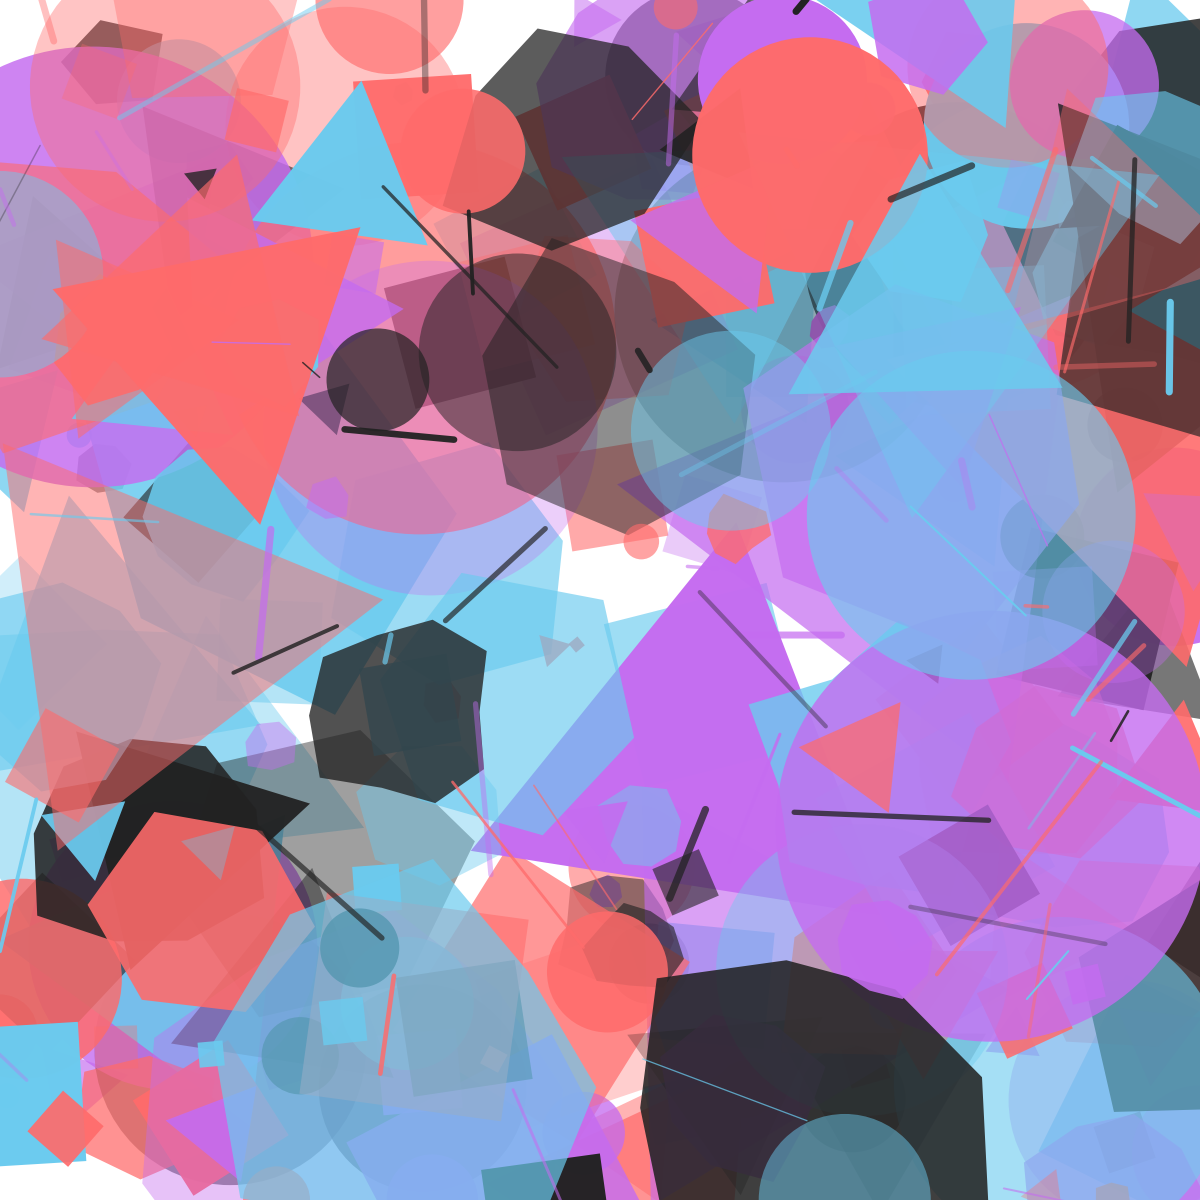

✅ Saved and displayed: quantum_art_preview.png


In [12]:
# --- Fast Quantum Art: pooled bits + optional quantum-seeded NumPy ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import math, os

# -------------------------
# Backend (shared)
# -------------------------
sim = AerSimulator()

# -------------------------
# Quantum bit pool (1 transpile, reused; refills in big batches)
# -------------------------
class QuantumBitPool:
    def __init__(self, n_qubits=64, shots=4096):
        self.n_qubits = n_qubits
        self.shots = shots
        self._buf = deque()
        self._tqc = None

    def _ensure_circ(self):
        if self._tqc is None:
            qc = QuantumCircuit(self.n_qubits, self.n_qubits)
            qc.h(range(self.n_qubits))
            qc.measure(range(self.n_qubits), range(self.n_qubits))
            self._tqc = transpile(qc, sim, optimization_level=0)

    def _refill(self):
        self._ensure_circ()
        res = sim.run(self._tqc, shots=self.shots, memory=True).result()
        mem = res.get_memory()  # list of bitstrings
        # push chars '0'/'1' into a single queue
        for s in mem:
            self._buf.extend(s)

    def bits(self, n):
        while len(self._buf) < n:
            self._refill()
        return ''.join(self._buf.popleft() for _ in range(n))

QB = QuantumBitPool(n_qubits=64, shots=4096)

# -------------------------
# Drop-in RNG using the pool
# -------------------------
def qrand_bits(n_bits: int) -> str:
    return QB.bits(n_bits)

def qrand_uint(max_val: int) -> int:
    if max_val <= 1:
        return 0
    n_bits = int(math.ceil(math.log2(max_val)))
    while True:
        x = int(qrand_bits(n_bits), 2)
        if x < max_val:
            return x

def qrand_float() -> float:
    # 32-bit resolution in [0,1)
    return int(qrand_bits(32), 2) / (2**32)

# -------------------------
# Optional ultra-fast mode: quantum-seeded NumPy RNG
# -------------------------
def quantum_seed_256():
    try:
        qc = QuantumCircuit(256, 256)
        qc.h(range(256)); qc.measure(range(256), range(256))
        tqc = transpile(qc, sim, optimization_level=0)
        res = sim.run(tqc, shots=1, memory=True).result()
        return int(res.get_memory()[0], 2)
    except Exception:
        # fallback if Aer isn't available in your env
        return int.from_bytes(os.urandom(32), "big")

_QSEED = quantum_seed_256()
RNG = np.random.default_rng(_QSEED)

# -------------------------
# Palettes & helpers
# -------------------------
PALETTES = [
    ["#222222", "#ff6b6b", "#ffd93d", "#6bcbef", "#c56cf0"],  # fixed hex
    ["#0b132b", "#1c2541", "#3a506b", "#5bc0be", "#e8eddf"],
    ["#2d132c", "#801336", "#c72c41", "#ee4540", "#f0f0f0"],
    ["#0f0f0f", "#00e5ff", "#00ffa6", "#ffd000", "#ff6bcb"],
    ["#1f1f1f", "#a29bfe", "#81ecec", "#55efc4", "#ffeaa7"]
]
SHAPES = ["circle", "square", "triangle", "line", "polygon"]

def choose_q(seq):
    return seq[qrand_uint(len(seq))]

def jitter_q(val, amount=0.05, low=0.0, high=1.0):
    v = val + (qrand_float() - 0.5) * 2 * amount
    return max(low, min(high, v))

def choose_np(seq):
    return seq[RNG.integers(0, len(seq))]

def jitter_np(val, amount=0.05, low=0.0, high=1.0):
    v = val + (RNG.random() - 0.5) * 2 * amount
    return max(low, min(high, v))

# -------------------------
# The art generator (keeps same signature)
# Set use_numpy_fast=True for maximum speed (quantum-seeded)
# -------------------------
def quantum_art(
    n_elements=250,
    figsize=(8, 8),
    bg_from_palette=True,
    save_path=None,
    use_numpy_fast=False,  # <-- toggle here
    dpi=150
):
    if use_numpy_fast:
        choose, jitter, rnd = choose_np, jitter_np, RNG.random
    else:
        choose, jitter, rnd = choose_q, jitter_q, qrand_float

    # Pick a palette + background
    palette = choose(PALETTES).copy()
    bg = choose(palette) if bg_from_palette else "#0a0a0a"
    try:
        palette.remove(bg)
    except ValueError:
        pass

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_facecolor(bg)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    for _ in range(n_elements):
        shape = choose(SHAPES)
        color = choose(palette)
        alpha = 0.3 + 0.7 * rnd()
        lw    = 0.5 + 3.0 * rnd()
        size  = 0.01 + 0.12 * rnd()
        x, y  = rnd(), rnd()
        x, y  = jitter(x, 0.08), jitter(y, 0.08)

        if shape == "circle":
            r = size * (0.5 + rnd())
            ax.add_patch(plt.Circle((x, y), r, fc=color, ec=None, alpha=alpha))

        elif shape == "square":
            s = size * (0.7 + rnd())
            ax.add_patch(plt.Rectangle((x - s/2, y - s/2), s, s,
                                       angle=360*rnd(),
                                       fc=color, ec=None, alpha=alpha))

        elif shape == "triangle":
            s = size * (0.9 + rnd())
            theta = 2*np.pi*rnd()
            pts = [[x + s*np.cos(theta+2*np.pi*k/3),
                    y + s*np.sin(theta+2*np.pi*k/3)] for k in range(3)]
            ax.add_patch(plt.Polygon(pts, closed=True, fc=color, ec=None, alpha=alpha))

        elif shape == "line":
            length = size * (1.0 + rnd())
            ang = 2*np.pi*rnd()
            x2, y2 = x + length*np.cos(ang), y + length*np.sin(ang)
            ax.plot([x, x2], [y, y2], linewidth=lw, alpha=alpha,
                    solid_capstyle="round", color=color)

        else:  # polygon
            k = (5 + (RNG.integers(0, 6) if use_numpy_fast else qrand_uint(6)))
            radius = size * (0.6 + rnd())
            theta0 = 2*np.pi*rnd()
            pts = []
            for i in range(k):
                ang = theta0 + 2*np.pi*i/k
                rr = radius*(0.8 + 0.4*rnd())
                pts.append([x + rr*np.cos(ang), y + rr*np.sin(ang)])
            ax.add_patch(plt.Polygon(pts, closed=True, fc=color, ec=None, alpha=alpha))

    plt.tight_layout(pad=0)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.show()

# -------------------------
# Quick benchmark helper
# -------------------------
def benchmark(n=100, use_numpy_fast=False):
    import time
    t0 = time.perf_counter()
    quantum_art(n_elements=n, use_numpy_fast=use_numpy_fast, dpi=120)
    dt = time.perf_counter() - t0
    print(f"{n} elements in {dt:.2f}s  →  ~{dt/n:.3f}s/element (use_numpy_fast={use_numpy_fast})")
# --- Ensure images display inline ---
import matplotlib
try:
    get_ipython  # exists if you're in Jupyter
    %matplotlib inline
    matplotlib.use('module://matplotlib_inline.backend_inline')
except Exception:
    pass

import matplotlib.pyplot as plt
plt.ion()

# --- Generate and display your art ---
out = "quantum_art_preview.png"
quantum_art(
    n_elements=300,
    use_numpy_fast=True,   # fastest mode
    dpi=150,
    save_path=out
)

# --- Show the image even if plt.show() failed ---
from IPython.display import display, Image
display(Image(filename=out))
print("✅ Saved and displayed:", out)


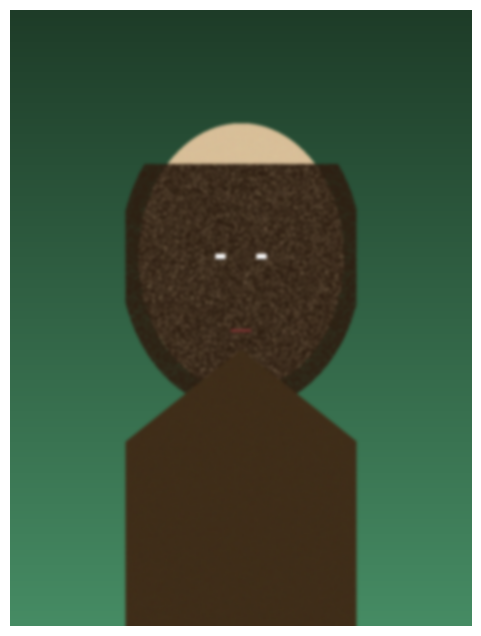

✅ Generated abstract Mona Lisa: mona_art.png


In [21]:
# === Abstract Quantum Mona Lisa ===
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import math, os

# Quantum-seeded RNG
def quantum_seed_256():
    try:
        from qiskit import QuantumCircuit, transpile
        from qiskit_aer import AerSimulator
        sim = AerSimulator()
        qc = QuantumCircuit(256, 256)
        qc.h(range(256)); qc.measure(range(256), range(256))
        tqc = transpile(qc, sim, optimization_level=0)
        res = sim.run(tqc, shots=1, memory=True).result()
        bits = res.get_memory()[0]
        return int(bits, 2)
    except Exception:
        return int.from_bytes(os.urandom(32), "big")

rng = np.random.default_rng(quantum_seed_256())

def smooth_noise(shape, scale=20):
    base = rng.normal(0, 1, shape)
    for _ in range(3):
        base = (base + np.roll(base, 1, axis=0) + np.roll(base, 1, axis=1)) / 3
    return base / base.max()

def paint_monalisa(canvas_size=(900,1200), save_path="mona_art.png"):
    w, h = canvas_size
    img = np.zeros((h, w, 3), dtype=float)

    # Background gradient
    for y in range(h):
        t = y / h
        bg = np.array([30 + 40*t, 60 + 80*t, 40 + 60*t]) / 255
        img[y, :, :] = bg

    # Head silhouette
    cx, cy = w//2, int(h*0.4)
    for y in range(h):
        for x in range(w):
            dx, dy = (x-cx)/200, (y-cy)/260
            d = dx*dx + dy*dy
            if d < 1.0:
                skin = np.array([0.85, 0.75, 0.6]) + rng.normal(0, 0.02, 3)
                img[y, x, :] = np.clip(skin, 0, 1)

    # Hair zone
    for y in range(int(h*0.25), int(h*0.7)):
        for x in range(int(w*0.25), int(w*0.75)):
            dx, dy = (x-cx)/220, (y-cy)/280
            if dx*dx + dy*dy < 1.15:
                if rng.random() < 0.9:
                    img[y, x, :] = np.clip([0.18, 0.12, 0.07] + rng.normal(0,0.01,3),0,1)

    # Dress (triangular zone)
    for y in range(int(h*0.55), h):
        for x in range(int(w*0.25), int(w*0.75)):
            if y > h*0.55 + abs(x-w/2)*0.8:
                img[y, x, :] = np.clip([0.25,0.18,0.1] + rng.normal(0,0.015,3), 0,1)

    # Add soft facial features via noise blending
    noise = smooth_noise((h,w))
    eye_y = int(h*0.4)
    mouth_y = int(h*0.52)

    for y in range(eye_y-5, eye_y+5):
        for side in [-1,1]:
            ex = int(w/2 + side*40)
            img[y, ex-10:ex+10, :] = [1,1,1]
            img[y+1, ex-6:ex+6, :] = [0,0,0]

    img[mouth_y-2:mouth_y+3, int(w/2-20):int(w/2+20), :] = [0.5,0.2,0.2]

    # Soft painterly blur
    final = Image.fromarray(np.uint8(np.clip(img*255,0,255)))
    final = final.filter(ImageFilter.GaussianBlur(radius=3))
    final.save(save_path)
    plt.figure(figsize=(6,8))
    plt.imshow(final)
    plt.axis("off")
    plt.show()
    print("✅ Generated abstract Mona Lisa:", save_path)

paint_monalisa()


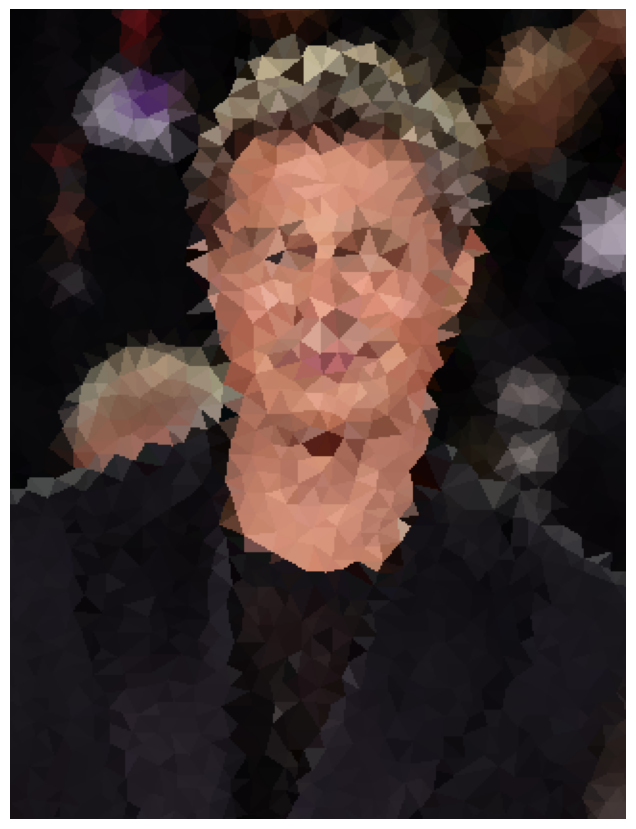

✓ Saved low-poly art to mona_lowpoly.png (size: 321×422, points: 1600)
